# 01 — Exploratory Data Analysis

Quick exploration of the dataset before modelling. The goal is to understand the data structure and observe churn-related patterns.

In [1]:
import sys
sys.path.append("..")

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import pandas as pd
import numpy as np

from src.data_loader import load_or_generate

sns.set_theme(style="whitegrid")

TARGET = "churned"


## 1. Load Dataset

In [2]:
df = load_or_generate()

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"Churn Rate: {df[TARGET].mean():.2%}")



Missing values detected.
Missing values handled.
Rows: 50,000
Columns: 12
Churn Rate: 23.76%


The dataset contains customer usage, subscription, and activity-related features.

## 2. Dataset Overview

In [3]:
df.head()

,customer_id,tenure_months,monthly_spend,num_support_tickets,last_login_days_ago,feature_adoption_score,plan_type,contract_type,region,has_referral,num_integrations,churned
0,C00000,52,213.12,1,35,0.268,Free,Annual,EMEA,0,12,0
1,C00001,15,141.39,2,17,0.100,Free,Month-to-Month,LATAM,1,4,1
2,C00002,61,73.17,4,79,0.051,Starter,Two-Year,LATAM,0,7,0
3,C00003,21,206.84,1,68,0.211,Free,Month-to-Month,Unknown,0,13,0
4,C00004,24,158.48,1,71,0.140,Free,Two-Year,EMEA,0,1,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             50000 non-null  object 
 1   tenure_months           50000 non-null  int64  
 2   monthly_spend           50000 non-null  float64
 3   num_support_tickets     50000 non-null  int64  
 4   last_login_days_ago     50000 non-null  int64  
 5   feature_adoption_score  50000 non-null  float64
 6   plan_type               50000 non-null  object 
 7   contract_type           50000 non-null  object 
 8   region                  50000 non-null  object 
 9   has_referral            50000 non-null  int64  
 10  num_integrations        50000 non-null  int64  
 11  churned                 50000 non-null  int64  
dtypes: float64(2), int64(6), object(4)
memory usage: 4.6+ MB


In [5]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
tenure_months,50000.0,35.91,20.52,1.00,18.00,36.00,54.00,71.00
monthly_spend,50000.0,120.44,120.10,0.01,34.86,83.10,167.26,1120.55
num_support_tickets,50000.0,1.50,1.23,0.00,1.00,1.00,2.00,8.00
last_login_days_ago,50000.0,44.47,25.93,0.00,22.00,44.00,67.00,89.00
feature_adoption_score,50000.0,0.29,0.16,0.00,0.16,0.26,0.39,0.94
has_referral,50000.0,0.30,0.46,0.00,0.00,0.00,1.00,1.00
num_integrations,50000.0,6.99,4.32,0.00,3.00,7.00,11.00,14.00
churned,50000.0,0.24,0.43,0.00,0.00,0.00,0.00,1.00


## 3. Missing Value Check

In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    print(missing)


No missing values found.


## 4. Class Imbalance Analysis

The dataset has a moderate class imbalance, but both classes are sufficiently represented.

         count   pct
churned             
0        38121  76.2
1        11879  23.8


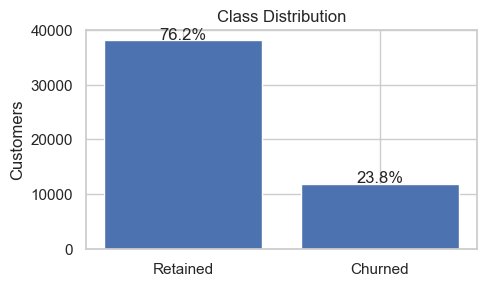

In [7]:
churn_counts = df[TARGET].value_counts()

churn_pct = (
    df[TARGET]
    .value_counts(normalize=True) * 100
)

print(pd.DataFrame({
    "count": churn_counts,
    "pct": churn_pct.round(1),
}))

fig, ax = plt.subplots(figsize=(5, 3))

bars = ax.bar(
    ["Retained", "Churned"],
    churn_counts.values,
    
)

for bar, pct in zip(
    bars,
    churn_pct.values,
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{pct:.1f}%",
        ha="center",
    )

ax.set_title("Class Distribution")
ax.set_ylabel("Customers")

plt.tight_layout(pad=1.0)
plt.show()


The retained class is larger, but the churned class is still well represented.

## 5. Feature Distributions

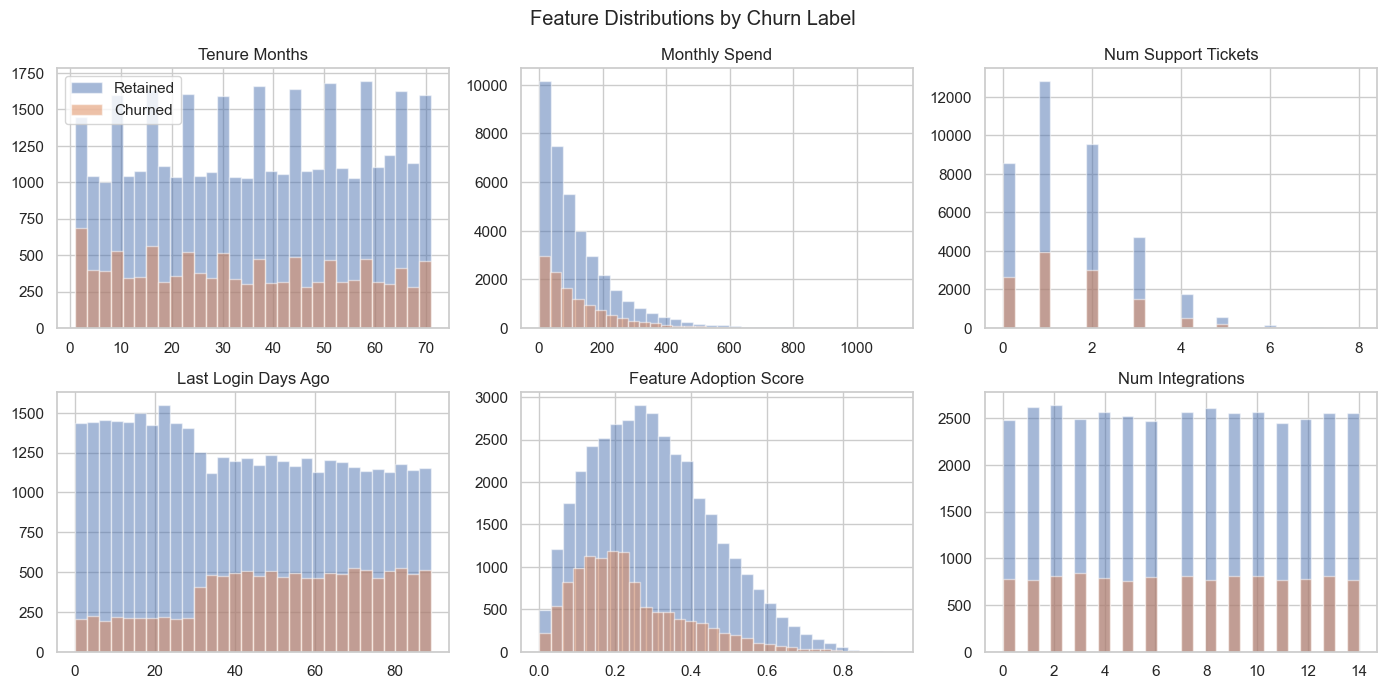

In [8]:
numeric_cols = [
    "tenure_months",
    "monthly_spend",
    "num_support_tickets",
    "last_login_days_ago",
    "feature_adoption_score",
    "num_integrations",
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for ax, col in zip(
    axes.flat,
    numeric_cols,
):

    for label, lbl in [
        (0, "Retained"),
        (1, "Churned"),
    ]:

        subset = df.loc[
            df[TARGET] == label,
            col,
        ]

        ax.hist(
            subset,
            bins=30,
            alpha=0.5,
            label=lbl,
        )

    ax.set_title(
        col.replace("_", " ").title()
    )

axes[0, 0].legend()

fig.suptitle(
    "Feature Distributions by Churn Label"
)

plt.tight_layout(pad=1.0)
plt.show()


### Quick observations

- Customers with lower feature adoption tend to churn more often
- Longer-tenure customers appear more stable
- Inactive users show higher churn behaviour


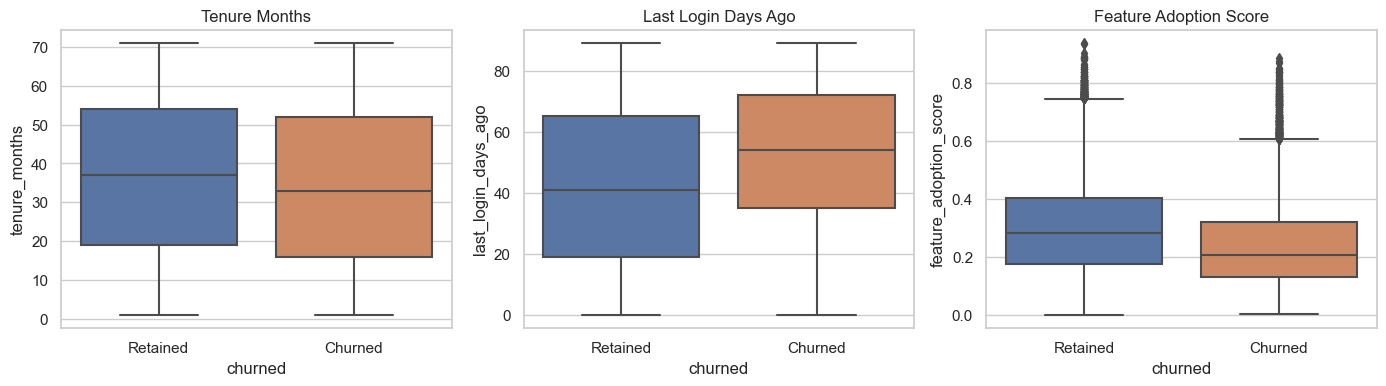

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(
    axes,
    [
        "tenure_months",
        "last_login_days_ago",
        "feature_adoption_score",
    ],
):

    sns.boxplot(
        data=df,
        x=TARGET,
        y=col,
        ax=ax,
    )

    ax.set_xticklabels(
        ["Retained", "Churned"]
    )

    ax.set_title(
        col.replace("_", " ").title()
    )

plt.tight_layout(pad=1.0)
plt.show()


## 6. Churn by Plan Type

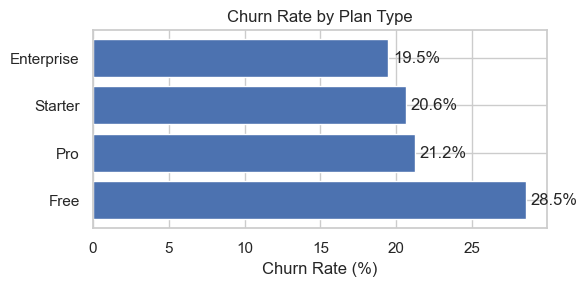

In [10]:
plan_churn = (
    df.groupby("plan_type")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plan_churn.columns = [
    "plan_type",
    "churn_rate",
]

plan_churn["churn_rate_pct"] = (
    plan_churn["churn_rate"] * 100
)

fig, ax = plt.subplots(figsize=(6, 3))

bars = ax.barh(
    plan_churn["plan_type"],
    plan_churn["churn_rate_pct"],
)

for bar, val in zip(
    bars,
    plan_churn["churn_rate_pct"],
):

    ax.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center",
    )

ax.set_xlabel("Churn Rate (%)")
ax.set_title("Churn Rate by Plan Type")

plt.tight_layout(pad=1.0)
plt.show()


Free plan customers show higher churn rates compared to paid plans.

## 7. Churn by Contract Type

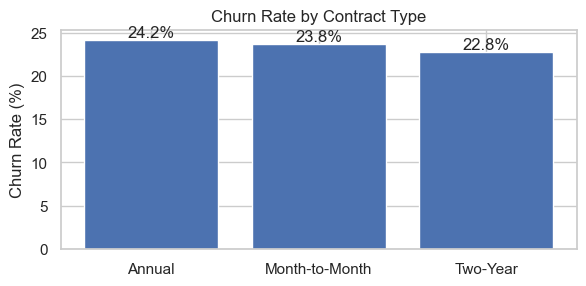

In [11]:
contract_churn = (
    df.groupby("contract_type")[TARGET]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

contract_churn.columns = [
    "contract_type",
    "churn_rate",
]

fig, ax = plt.subplots(figsize=(6, 3))

bars = ax.bar(
    contract_churn["contract_type"],
    contract_churn["churn_rate"] * 100,
    
)

for bar, val in zip(
    bars,
    contract_churn["churn_rate"],
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val:.1%}",
        ha="center",
    )

ax.set_ylabel("Churn Rate (%)")
ax.set_title("Churn Rate by Contract Type")

plt.tight_layout(pad=1.0)
plt.show()


Month-to-month customers churn more frequently than long-term contract users.

## 8. Correlation Analysis

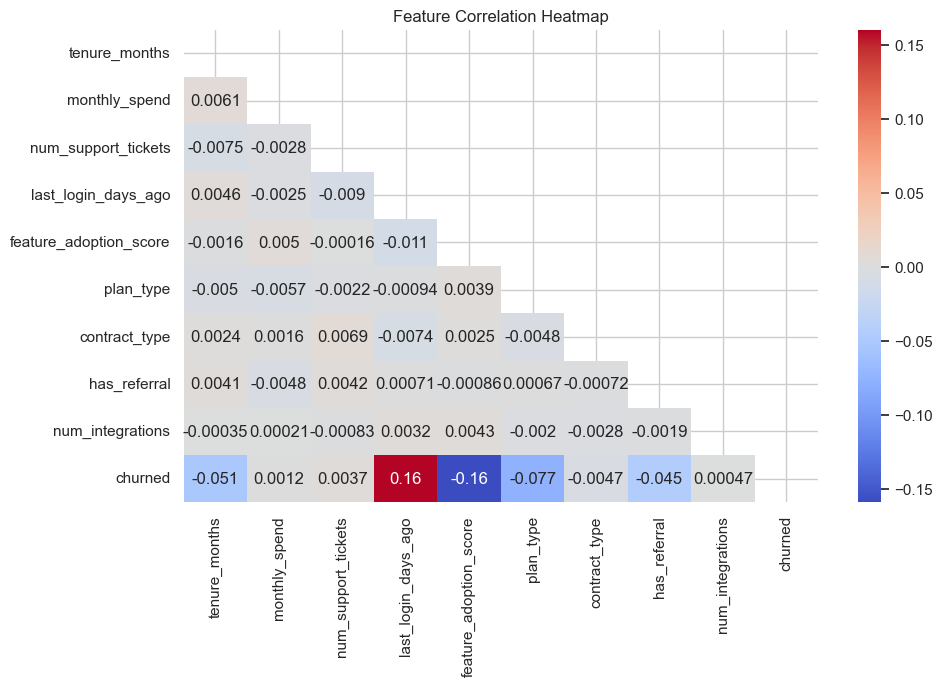

In [12]:
df_corr = df.copy()

df_corr["plan_type"] = df_corr["plan_type"].map({
    "Free": 0,
    "Starter": 1,
    "Pro": 2,
    "Enterprise": 3,
})

df_corr["contract_type"] = df_corr["contract_type"].map({
    "Month-to-Month": 0,
    "Annual": 1,
    "Two-Year": 2,
})

df_corr = df_corr.drop(
    columns=["customer_id", "region"]
)

corr_matrix = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 7))

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="coolwarm",
    annot=True,
    
)

ax.set_title("Feature Correlation Heatmap")

plt.tight_layout(pad=1.0)
plt.show()


In [13]:
churn_corr = (
    corr_matrix[TARGET]
    .drop(TARGET)
    .sort_values(
        key=abs,
        ascending=False,
    )
)

print("Top correlations with churn:\n")

print(churn_corr.to_string())


Top correlations with churn:

last_login_days_ago       0.160155
feature_adoption_score   -0.158979
plan_type                -0.076590
tenure_months            -0.050598
has_referral             -0.045024
contract_type            -0.004673
num_support_tickets       0.003733
monthly_spend             0.001243
num_integrations          0.000468


## 9. Key Business Insights

1. Customers with low feature adoption tend to churn more often.

2. Users inactive for longer periods show higher churn behaviour.

3. Free-tier customers have higher churn rates than paid plans.

4. Customers with longer contracts appear more stable.

5. Newer customers with multiple support tickets show elevated churn risk.
